# 02 · Amenity detection with OWL-ViT

**Goal:** find the amenity in each photo reliably enough to crop it and ask questions about it, without training a detector.

**Why OWL-ViT.** I wanted a Vision Transformer that detects objects from a text prompt out of the box. OWL-ViT is open-vocabulary: you give it "kettle" and it returns boxes and confidence scores. No fine-tuning, so new amenities only need a new prompt. The focus of the project is question generation, so detection had to work zero-shot.

**What I tested for each amenity**
- **Prompt style:** *baseline* (just the name), *long* (a descriptive phrase), *variants* (several synonyms at once). Kettle also got "electric kettle", since most hotel kettles are electric.
- **Confidence threshold:** a sweep from 0.05 to 0.45 instead of one fixed value.
- **Scoring:** a box counts as correct when IoU with an annotated box is above 0.5. Boxes are matched in score order and each annotated object can be matched once. Extra boxes count as false positives, missed objects as false negatives.
- **Negatives:** how often a photo without the amenity still gets a box.

In [1]:
import sys, json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

ROOT = Path("..").resolve()
sys.path.insert(0, str(ROOT / "src"))

from amenity_qgen import config, plotting
from amenity_qgen.plotting import SERIES, MUTED, TEXT, TEXT_2

plotting.use_style()
pd.set_option("display.max_colwidth", 120)
FIG = ROOT / "results" / "figures"
AMENITIES = ["bathtub", "kettle", "hairdryer", "mirror", "tv"]
NAMES = {"bathtub": "Bathtub", "kettle": "Kettle", "hairdryer": "Hairdryer", "mirror": "Mirror", "tv": "TV"}

In [2]:
prompts = pd.DataFrame(
    [(NAMES[am], name, " | ".join(p)) for am in AMENITIES for name, p in config.AMENITIES[am]["prompts"].items()],
    columns=["amenity", "prompt set", "text prompts"],
)
prompts

,amenity,prompt set,text prompts
0,Bathtub,baseline,bathtub
1,Bathtub,long,"white ceramic bathtub in hotel bathroom, rectangular or oval-shaped"
2,Bathtub,variants,bathtub | white bathtub | ceramic bathtub | built-in bathtub | freestanding bathtub | hotel bathtub | bathtub with s...
3,Kettle,baseline,kettle
4,Kettle,electric,electric kettle
5,Kettle,long,stainless steel electric kettle
6,Kettle,variants,kettle | electric kettle | stainless steel kettle | gooseneck kettle
7,Hairdryer,baseline,hairdryer
8,Hairdryer,long,black and silver electric hairdryer on a bathroom wall
9,Hairdryer,variants,hairdryer | electric hair dryer | wall-mounted hotel hairdryer | portable travel hair dryer


## Running the detector
The detections were produced on trivago's GPU environment. The code is below; `RUN_DETECTION` is off so the notebook reads the saved detections in `results/detection/raw_detections` instead.

In [3]:
RUN_DETECTION = False

if RUN_DETECTION:
    from amenity_qgen.detection import load_owlvit, run_prompt_set
    processor, model, device = load_owlvit()
    for am in AMENITIES:
        for name, text in config.AMENITIES[am]["prompts"].items():
            dets = run_prompt_set(IMAGE_DIR[am], ANNOTATIONS[am], text, processor, model, device)
            dets.to_csv(ROOT / "results" / "detection" / "raw_detections" / f"dets_{am}_{name}.csv", index=False)

## Threshold sweep

In [4]:
from amenity_qgen.detection import load_ground_truth, threshold_sweep, best_operating_point

sweeps = []
for am in AMENITIES:
    gt = load_ground_truth(ROOT / "data" / "annotations" / f"{am}_test.coco.json")
    for name in config.AMENITIES[am]["prompts"]:
        dets = pd.read_csv(ROOT / "results" / "detection" / "raw_detections" / f"dets_{am}_{name}.csv")
        sweeps.append(threshold_sweep(dets, gt, config.CONF_SWEEP, prompt=name).assign(amenity=am))
sweep = pd.concat(sweeps, ignore_index=True)[["amenity", "prompt", "conf", "precision", "recall", "f1", "mean_iou", "tp", "fp", "fn"]]
sweep.to_csv(ROOT / "results" / "detection" / "threshold_sweep.csv", index=False)

best = pd.concat([best_operating_point(sweep[sweep.amenity == am]) for am in AMENITIES])
best.round(3)

,amenity,prompt,conf,precision,recall,f1,mean_iou,tp,fp,fn
0,bathtub,baseline,0.05,0.678,0.866,0.760,0.641,187,89,29
11,bathtub,variants,0.15,0.645,0.731,0.685,0.615,158,87,58
5,bathtub,long,0.05,0.552,0.736,0.631,0.553,159,129,57
20,kettle,electric,0.05,0.727,0.662,0.693,0.604,133,50,68
26,kettle,long,0.15,0.705,0.677,0.690,0.583,136,57,65
31,kettle,variants,0.15,0.754,0.627,0.685,0.627,126,41,75
15,kettle,baseline,0.05,0.650,0.721,0.684,0.573,145,78,56
46,hairdryer,variants,0.15,0.782,0.735,0.758,0.699,158,44,57
35,hairdryer,baseline,0.05,0.766,0.716,0.740,0.690,154,47,61
40,hairdryer,long,0.05,0.759,0.307,0.437,0.715,66,21,149


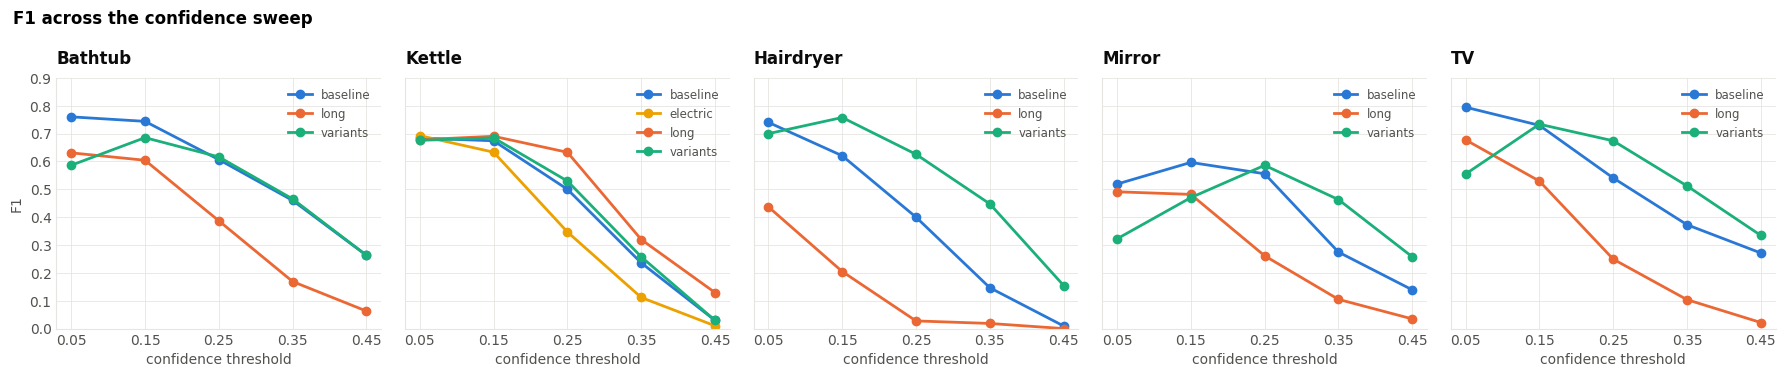

In [5]:
fig, axes = plt.subplots(1, 5, figsize=(18, 3.8), sharey=True)
for ax, am in zip(axes, AMENITIES):
    s = sweep[sweep.amenity == am]
    for name in config.AMENITIES[am]["prompts"]:
        d = s[s.prompt == name]
        ax.plot(d.conf, d.f1, marker="o", color=plotting.PROMPT_COLORS[name], label=name)
    ax.set_title(NAMES[am]); ax.set_xlabel("confidence threshold"); ax.set_xticks(config.CONF_SWEEP)
    ax.legend(fontsize=8.5, loc="upper right")
axes[0].set_ylabel("F1"); axes[0].set_ylim(0, 0.9)
fig.suptitle("F1 across the confidence sweep", x=0.01, ha="left", fontweight="bold")
plt.tight_layout(); fig.savefig(FIG / "det_f1_vs_threshold.png"); plt.show()

Every amenity peaks at a low threshold (0.05 or 0.15). OWL-ViT is not very confident about small, partly hidden objects in busy rooms, so a default threshold of around 0.3 would throw away most correct detections.

## Prompt comparison at each prompt's best threshold

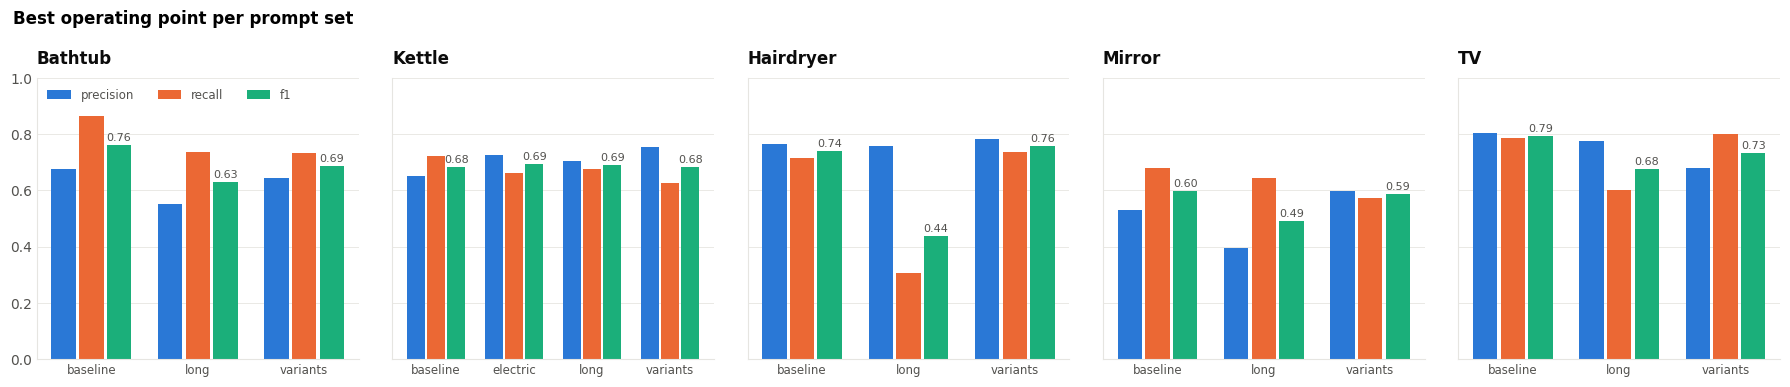

In [6]:
fig, axes = plt.subplots(1, 5, figsize=(18, 3.9), sharey=True)
metrics = ["precision", "recall", "f1"]
for ax, am in zip(axes, AMENITIES):
    b = best[best.amenity == am].set_index("prompt").loc[list(config.AMENITIES[am]["prompts"])]
    x = np.arange(len(b)); w = 0.26
    for k, m in enumerate(metrics):
        ax.bar(x + (k - 1) * w, b[m], w - 0.03, color=SERIES[k], label=m if am == "bathtub" else None)
    for xi, v in zip(x, b.f1):
        ax.annotate(f"{v:.2f}", (xi + w, v), xytext=(0, 3), textcoords="offset points", ha="center", fontsize=8, color=TEXT_2)
    ax.set_xticks(x); ax.set_xticklabels(b.index, fontsize=8.5); ax.set_title(NAMES[am]); ax.grid(axis="x", visible=False)
axes[0].set_ylim(0, 1); axes[0].legend(loc="upper left", fontsize=8.5, ncol=3)
fig.suptitle("Best operating point per prompt set", x=0.01, ha="left", fontweight="bold")
plt.tight_layout(); fig.savefig(FIG / "det_prompt_comparison.png"); plt.show()

## Selected configuration
The prompt and threshold passed on to question generation, per amenity.

In [7]:
sel = []
for am in AMENITIES:
    name, conf = config.AMENITIES[am]["selected"]
    r = sweep[(sweep.amenity == am) & (sweep.prompt == name) & (np.isclose(sweep.conf, conf))].iloc[0]
    sel.append(dict(amenity=NAMES[am], prompt=name, threshold=conf, precision=r.precision, recall=r.recall, f1=r.f1, mean_iou=r.mean_iou))
summary = pd.DataFrame(sel).sort_values("f1", ascending=False)
summary.to_csv(ROOT / "results" / "detection" / "detection_summary.csv", index=False)
summary.round(3)

,amenity,prompt,threshold,precision,recall,f1,mean_iou
4,TV,baseline,0.05,0.805,0.785,0.795,0.750
0,Bathtub,baseline,0.05,0.678,0.866,0.760,0.641
2,Hairdryer,baseline,0.05,0.766,0.716,0.740,0.690
1,Kettle,electric,0.05,0.727,0.662,0.693,0.604
3,Mirror,baseline,0.15,0.531,0.681,0.597,0.633


- **TV** is the easiest: a standard shape, and the plain prompt works best.
- **Bathtub:** baseline wins clearly. Errors come from shower trays, tiled platforms, and tubs hidden behind glass or curtains.
- **Kettle:** all four prompts land within 0.01 F1. "Electric kettle" has the best F1 and clearly higher precision than the plain prompt at the same threshold (0.73 vs 0.65): fewer coffee machines and metal containers get mistaken for kettles.
- **Hairdryer:** variants edge out baseline (0.758 at 0.15 vs 0.740). Baseline was kept for generation: one plain prompt across all amenities, with a small gap. The long prompt collapses recall to 0.31.
- **Mirror** is the hardest: windows, glass cabinets, framed pictures and glossy panels all look like mirrors, and many photos contain several.

## False detections on photos without the amenity

amenity,Bathtub,Hairdryer,Kettle,Mirror,TV
conf,,,,,
0.05,0.763,0.627,0.775,0.688,0.967
0.15,0.895,0.973,0.930,0.925,1.000
0.25,0.961,1.000,0.958,0.978,1.000
0.35,0.974,1.000,0.986,1.000,1.000
0.45,1.000,1.000,0.986,1.000,1.000


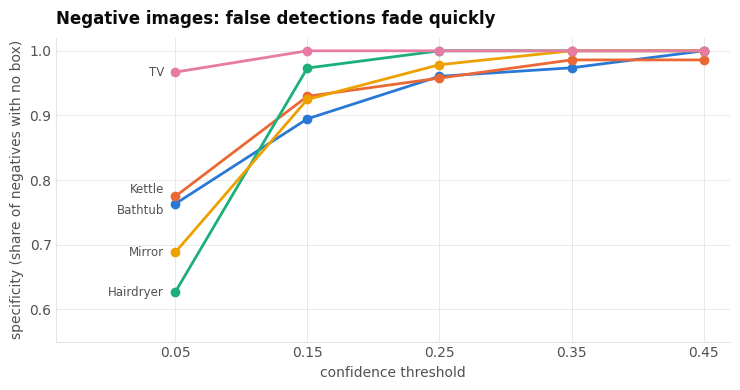

In [8]:
neg = pd.concat([pd.read_csv(ROOT / "results" / "detection" / f"negatives_{am}.csv").assign(amenity=am) for am in AMENITIES])
neg = neg[neg.conf.isin(config.CONF_SWEEP)]
display(neg.pivot(index="conf", columns="amenity", values="specificity").rename(columns=NAMES).round(3))

fig, ax = plt.subplots(figsize=(7.5, 4))
for i, am in enumerate(AMENITIES):
    d = neg[neg.amenity == am]
    ax.plot(d.conf, d.specificity, marker="o", color=(SERIES + ["#e87ba4"])[i])
    nudge = {"kettle": 5, "bathtub": -5}.get(am, 0)
    ax.annotate(NAMES[am], (d.conf.iloc[0], d.specificity.iloc[0]), xytext=(-8, nudge), textcoords="offset points", ha="right", va="center", fontsize=8.5, color=TEXT_2)
ax.set_xlim(-0.04, 0.47); ax.set_xticks(config.CONF_SWEEP); ax.set_ylim(0.55, 1.02)
ax.set_xlabel("confidence threshold"); ax.set_ylabel("specificity (share of negatives with no box)")
ax.set_title("Negative images: false detections fade quickly")
plt.tight_layout(); fig.savefig(FIG / "det_negatives.png"); plt.show()

Most false detections sit at the lowest threshold. By 0.15, specificity is above 0.89 for every amenity. TV, hairdryer, mirror and bathtub reach 1.0 between 0.15 and 0.45. Kettle keeps a single false image even at 0.45. This is the trade-off behind the selected thresholds: keep recall high, and let the question-generation quality gate catch the rest.

## Detections on sample photos

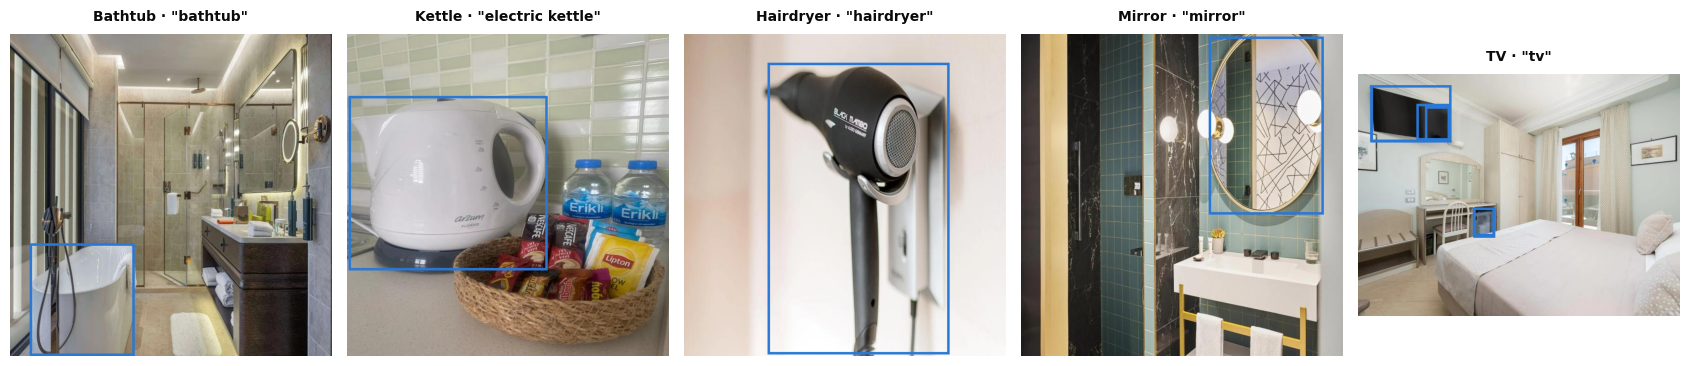

In [9]:
from PIL import Image, ImageDraw

manifest = pd.read_csv(ROOT / "data" / "sample_manifest.csv")
fig, axes = plt.subplots(1, 5, figsize=(17, 3.9))
for ax, am in zip(axes, AMENITIES):
    name, conf = config.AMENITIES[am]["selected"]
    f = manifest[(manifest.amenity == am) & (manifest.kind == "positive")].file.iloc[1]
    dets = pd.read_csv(ROOT / "results" / "detection" / "raw_detections" / f"dets_{am}_{name}.csv")
    img = Image.open(ROOT / "data" / "sample" / am / f).convert("RGB"); draw = ImageDraw.Draw(img)
    for _, r in dets[(dets.image == f) & (dets.score > conf)].iterrows():
        draw.rectangle([r.x1, r.y1, r.x2, r.y2], outline=(42, 120, 214), width=5)
    ax.imshow(img); ax.set_axis_off(); ax.set_title(f"{NAMES[am]} · \"{config.AMENITIES[am]['prompts'][name][0]}\"", loc="center", fontsize=10)
plt.tight_layout(); fig.savefig(FIG / "det_examples.png", dpi=100); plt.show()

## Takeaways
- Zero-shot detection works for hotel amenities without any training, but only when the prompt and threshold are tuned per amenity.
- **Plain prompts win.** Adding description made detection worse for bathtub, hairdryer, mirror and TV. For kettle, all prompts were within 0.01 of each other.
- **Low thresholds win.** Question generation needs coverage, so recall matters more than tight boxes. Mean IoU barely moves between prompts at their best points.
- Mirror is the weak spot and the main candidate for amenity-specific work.